# Proyecto de empresa aliada: Entrega Final

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import silhouette_score
import seaborn as sb
import warnings
from sklearn import decomposition
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

## 1. Cargas de Datos

In [3]:
# Cargar dimensiones
df_prod = pd.read_excel("DIM_PRODUCT.xlsx")
df_seg = pd.read_excel("DIM_SEGMENT.xlsx")
df_cat = pd.read_csv("DIM_CATEGORY.csv")
df_sales = pd.read_csv("FACT_SALES.csv")


## 2. Limpieza y Transformación de Datos (Python)

In [ ]:
# Merge 1: Producto + Segmento
df_full = df_prod.merge(
    df_seg,
    how="left",
    left_on=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"],
    right_on=["CATEGORY", "ATTR1", "ATTR2", "ATTR3", "FORMAT"]
)

In [4]:
df_sales

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5
...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO
121998,26-23,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO
121999,26-23,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO


In [5]:
# Merge 2: Agregar ventas
df_full = df_full.merge(
    df_sales,
    left_on="ITEM", 
    right_on="ITEM_CODE", 
    how="left"
)

df_full.head()

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,45-22,0000075000592,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,48-22,0000075000592,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,03-22,0000075000592,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,05-22,0000075000592,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,09-22,0000075000592,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO


In [6]:
df_cluster = df_full[df_full["BRAND"].str.contains("VANISH", na=False)]


In [7]:

# Variables numéricas
num_cols = ["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES"]

# Variables categóricas a dummies
cat_cols = ["FORMAT", "REGION", "SEGMENT"]

df_model = pd.get_dummies(df_cluster[num_cols + cat_cols], drop_first=True)


In [8]:
df_model.head()

,TOTAL_VALUE_SALES,TOTAL_UNIT_SALES,FORMAT_GEL,FORMAT_LIQUIDO,FORMAT_POLVO,REGION_TOTAL AUTOS AREA 2,REGION_TOTAL AUTOS AREA 3,REGION_TOTAL AUTOS AREA 4,REGION_TOTAL AUTOS AREA 5,REGION_TOTAL AUTOS AREA 6,REGION_TOTAL AUTOS SCANNING MEXICO,SEGMENT_LIQUID & GEL,SEGMENT_POWDER,SEGMENT_PRETREAT
46351,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False
46352,0.058,0.001,False,False,True,True,False,False,False,False,False,False,True,False
46353,0.175,0.003,False,False,True,True,False,False,False,False,False,False,True,False
46354,0.486,0.009,False,False,True,False,False,False,True,False,False,False,True,False
46355,0.117,0.002,False,False,True,False,False,False,False,False,True,False,True,False


In [9]:
df_model_clean = df_model.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model_clean)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_model_clean.columns)


In [10]:
df_cluster_clean = df_cluster.loc[df_model_clean.index].copy()


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster_clean["Cluster"] = kmeans.fit_predict(X_scaled_df)
df_cluster_clean.columns

Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'SEGMENT', 'WEEK', 'ITEM_CODE',
       'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES',
       'REGION', 'Cluster'],
      dtype='object')

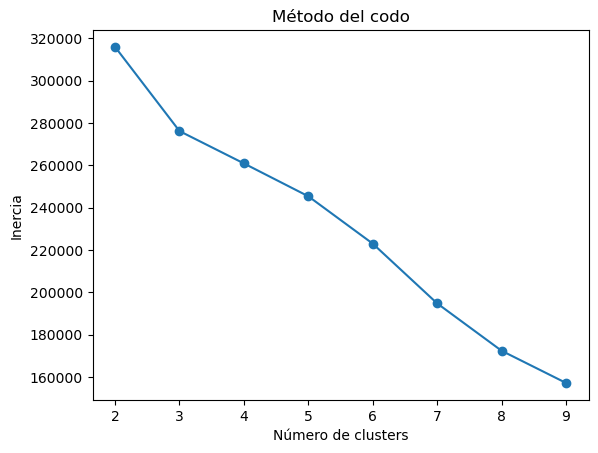

In [11]:

inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_df)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()


In [12]:
df_cluster_clean.columns

Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'SEGMENT', 'WEEK', 'ITEM_CODE',
       'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES',
       'REGION', 'Cluster'],
      dtype='object')

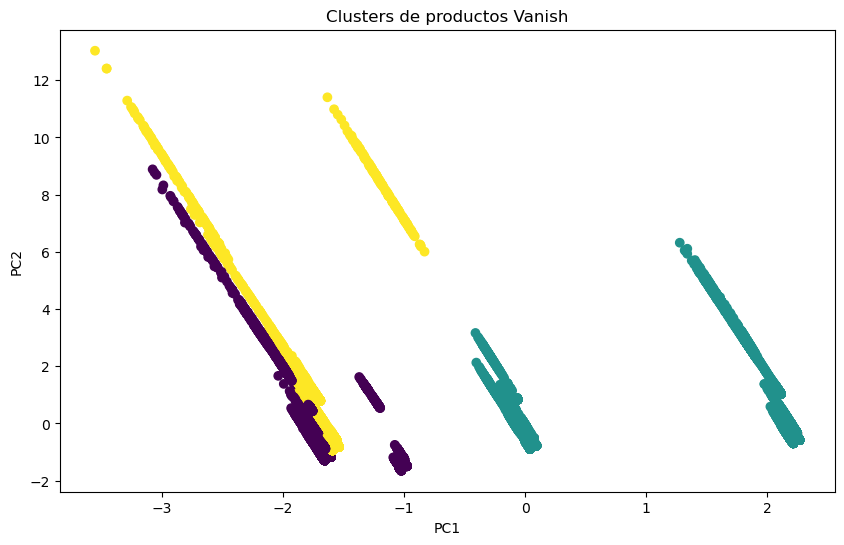

In [13]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled_df)

df_cluster_clean["PC1"] = components[:,0]
df_cluster_clean["PC2"] = components[:,1]

plt.figure(figsize=(10,6))
plt.scatter(
    df_cluster_clean["PC1"],
    df_cluster_clean["PC2"],
    c=df_cluster_clean["Cluster"],
    cmap="viridis"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de productos Vanish")
plt.show()


Clusters: 2, Silhouette: 0.2334
Clusters: 3, Silhouette: 0.2800
Clusters: 4, Silhouette: 0.2534
Clusters: 5, Silhouette: 0.2576
Clusters: 6, Silhouette: 0.2701
Clusters: 7, Silhouette: 0.2909
Clusters: 8, Silhouette: 0.2884
Clusters: 9, Silhouette: 0.3268


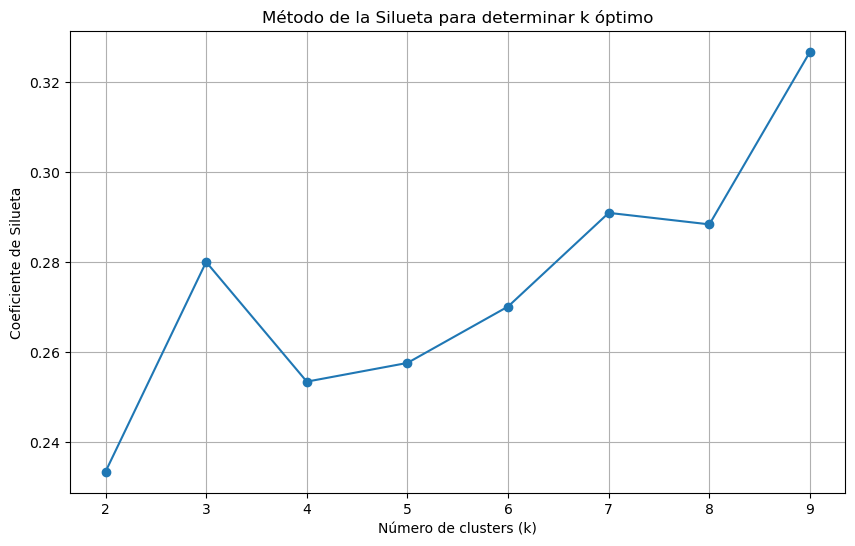

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# Determinar el numero de grupos optimo con el Criterio de la Silueta ('Silhouette')
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {k}, Silhouette: {score:.4f}")

# Gráfica
plt.figure(figsize=(10,6))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Método de la Silueta para determinar k óptimo")
plt.grid(True)
plt.show()


# Evaluar los resultados del clustering

✔ Productos asignados en cada cluster

In [16]:
df_cluster_clean["Cluster"].value_counts()

Cluster
1    14074
0     8331
2     5972
Name: count, dtype: int64

✔ Productos por cluster

In [15]:
for c in sorted(df_cluster_clean["Cluster"].unique()):
    print(f"\nCluster {c}")
    display(df_cluster_clean[df_cluster_clean["Cluster"] == c].head(5))


Cluster 0


,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,Cluster,PC1,PC2
47254,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL,06-22,7501058715029,0.007,0.140,7.0,TOTAL AUTOS AREA 2,0,-1.668588,-1.166982
47255,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL,05-22,7501058715029,0.011,0.205,11.0,TOTAL AUTOS SCANNING MEXICO,0,-1.758847,0.438841
47256,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL,16-22,7501058715029,0.001,0.019,1.0,TOTAL AUTOS AREA 1,0,-1.656556,-0.893389
47257,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL,16-22,7501058715029,0.001,0.019,1.0,TOTAL AUTOS SCANNING MEXICO,0,-1.758569,0.437003
47258,RECKITT,VANISH,7501058715029,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL,01-22,7501058715029,0.009,0.180,9.0,TOTAL AUTOS AREA 2,0,-1.668646,-1.166603



Cluster 1


,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,Cluster,PC1,PC2
46352,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,44-22,7501058712813,0.001,0.058,1.0,TOTAL AUTOS AREA 2,1,2.202582,-0.566134
46353,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,06-22,7501058712813,0.003,0.175,1.5,TOTAL AUTOS AREA 2,1,2.202473,-0.565433
46354,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,13-22,7501058712813,0.009,0.486,4.5,TOTAL AUTOS AREA 5,1,2.246879,-0.331938
46355,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,35-22,7501058712813,0.002,0.117,1.0,TOTAL AUTOS SCANNING MEXICO,1,2.112373,1.039346
46356,RECKITT,VANISH,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,12-22,7501058712813,0.001,0.059,1.0,TOTAL AUTOS AREA 3,1,2.267151,-0.573590



Cluster 2


,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,Cluster,PC1,PC2
46627,RECKITT,VANISH,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,1,BARRA,SAFE BLEACH,FABRIC TREATMENT,ROSA,BAR,10-22,7501058714596,42.983,494.274,17.940,TOTAL AUTOS SCANNING MEXICO,2,-1.049205,7.465160
46630,RECKITT,VANISH,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,1,BARRA,SAFE BLEACH,FABRIC TREATMENT,ROSA,BAR,35-22,7501058714596,63.734,810.082,28.164,TOTAL AUTOS SCANNING MEXICO,2,-1.578629,10.986881
46631,RECKITT,VANISH,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,1,BARRA,SAFE BLEACH,FABRIC TREATMENT,ROSA,BAR,48-22,7501058714596,55.375,681.886,23.424,TOTAL AUTOS SCANNING MEXICO,2,-1.364700,9.564155
46637,RECKITT,VANISH,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,1,BARRA,SAFE BLEACH,FABRIC TREATMENT,ROSA,BAR,05-22,7501058714596,45.056,516.059,18.618,TOTAL AUTOS SCANNING MEXICO,2,-1.095477,7.776244
46647,RECKITT,VANISH,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,1,BARRA,SAFE BLEACH,FABRIC TREATMENT,ROSA,BAR,44-22,7501058714596,56.939,704.321,24.984,TOTAL AUTOS SCANNING MEXICO,2,-1.403676,9.823883


✔ Composición por atributos

In [17]:
df_cluster_clean.groupby("Cluster")[["FORMAT", "ATTR3", "SEGMENT"]].agg(lambda x: x.value_counts().head(3))

,FORMAT,ATTR3,SEGMENT
Cluster,,,
0,8331,"[5117, 3214]","[7211, 1120]"
1,"[11155, 2919]","[7764, 6310]","[11155, 2919]"
2,"[5812, 160]","[3533, 2439]","[5812, 160]"


✔ Analizar variables numéricas (ventas, unidades)

In [18]:
df_cluster_clean.groupby("Cluster")[["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES"]].mean()

,TOTAL_VALUE_SALES,TOTAL_UNIT_SALES
Cluster,,
0,86.182500,1.234659
1,60.196012,1.653558
2,100.988689,3.646153


✔ Segmentos dominantes por cluster

In [19]:
df_cluster_clean.groupby("Cluster")["SEGMENT"].value_counts(normalize=True)

Cluster  SEGMENT     
0        LIQUID & GEL    0.865562
         PRETREAT        0.134438
1        POWDER          0.792596
         BAR             0.207404
2        LIQUID & GEL    0.973208
         BAR             0.026792
Name: proportion, dtype: float64

✔ Atributos dominantes (ROSA, BLANCO, PRE-LAVADOR…)

In [20]:
df_cluster_clean.groupby("Cluster")["ATTR3"].value_counts(normalize=True)

Cluster  ATTR3 
0        ROSA      0.614212
         BLANCO    0.385788
1        ROSA      0.551656
         BLANCO    0.448344
2        ROSA      0.591594
         BLANCO    0.408406
Name: proportion, dtype: float64

✔ Formatos dominantes (LIQUIDO, POLVO, GEL)

In [21]:
df_cluster_clean.groupby("Cluster")["FORMAT"].value_counts(normalize=True)

Cluster  FORMAT 
0        LIQUIDO    1.000000
1        POLVO      0.792596
         BARRA      0.207404
2        GEL        0.973208
         BARRA      0.026792
Name: proportion, dtype: float64

# Graficos

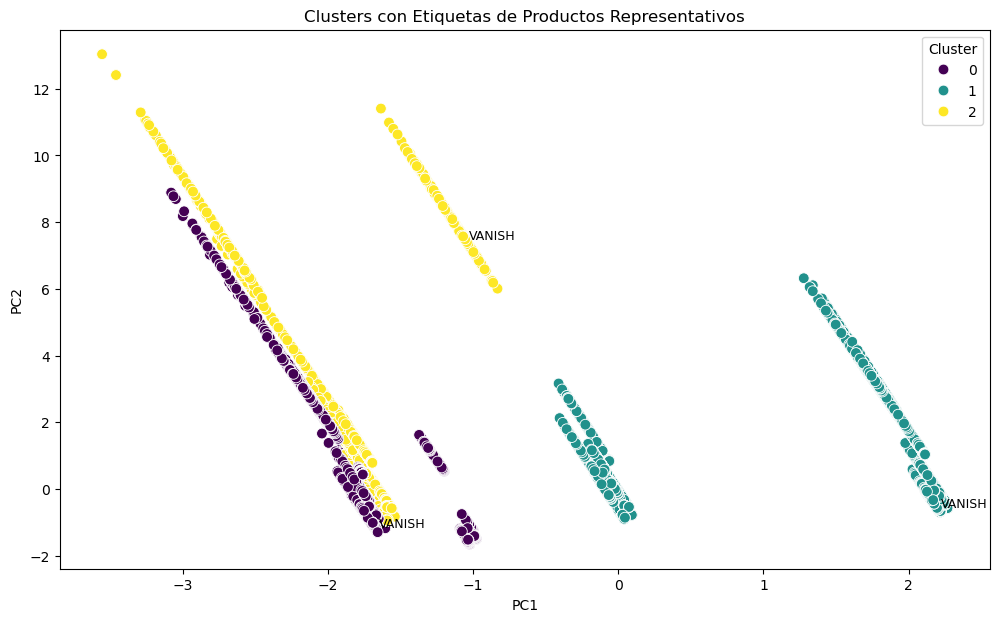

In [22]:
plt.figure(figsize=(12,7))
sb.scatterplot(
    data=df_cluster_clean,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=60
)

# Etiquetar un producto representativo por cluster
for c in df_cluster_clean["Cluster"].unique():
    sample = df_cluster_clean[df_cluster_clean["Cluster"] == c].iloc[0]
    plt.text(
        sample["PC1"] + 0.02,
        sample["PC2"] + 0.02,
        sample["BRAND"],
        fontsize=9
    )

plt.title("Clusters con Etiquetas de Productos Representativos")
plt.show()


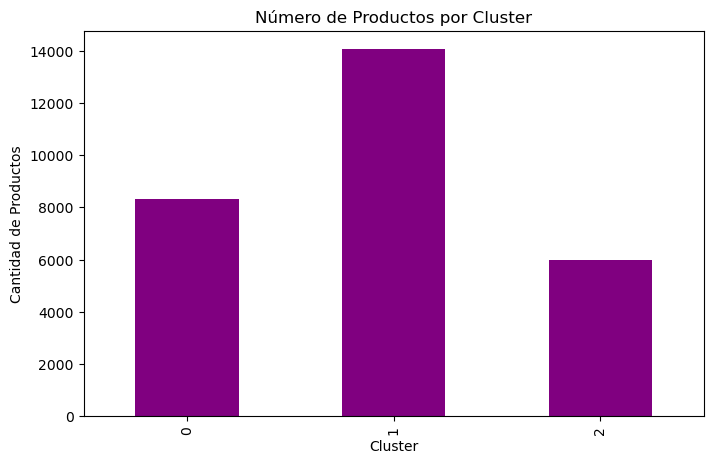

In [23]:
plt.figure(figsize=(8,5))
df_cluster_clean["Cluster"].value_counts().sort_index().plot(kind="bar", color="purple")

plt.title("Número de Productos por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de Productos")
plt.show()


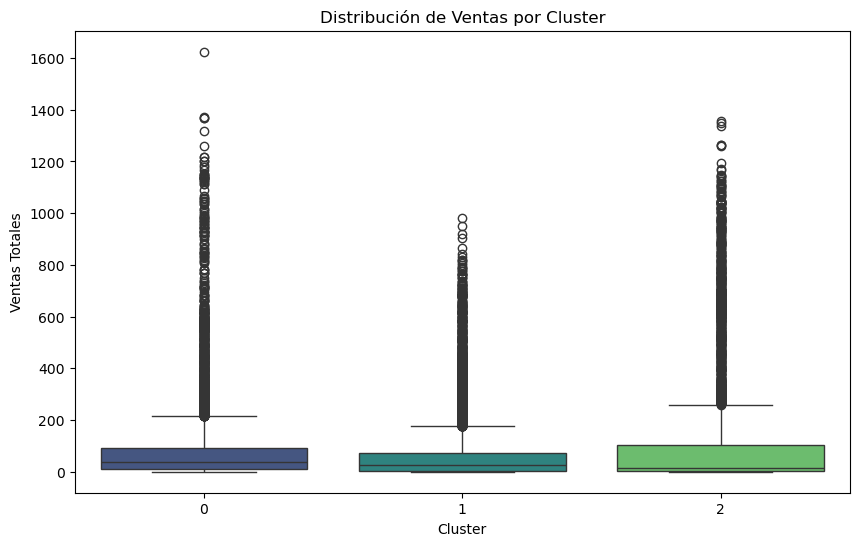

In [24]:
plt.figure(figsize=(10,6))
sb.boxplot(
    data=df_cluster_clean,
    x="Cluster",
    y="TOTAL_VALUE_SALES",
    palette="viridis"
)

plt.title("Distribución de Ventas por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Ventas Totales")
plt.show()


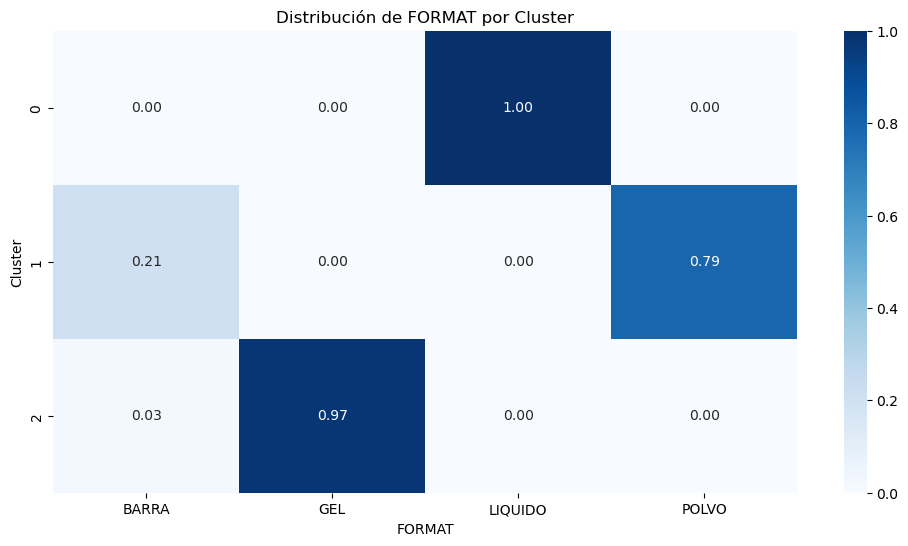

In [25]:
format_cluster = pd.crosstab(df_cluster_clean["Cluster"], df_cluster_clean["FORMAT"], normalize="index")

plt.figure(figsize=(12,6))
sb.heatmap(format_cluster, annot=True, cmap="Blues", fmt=".2f")
plt.title("Distribución de FORMAT por Cluster")
plt.show()


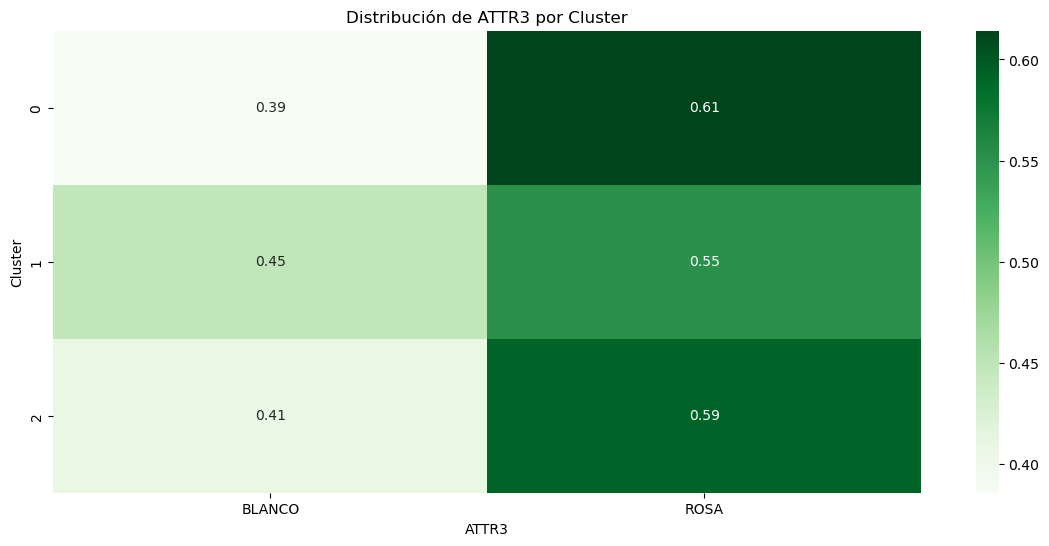

In [26]:
attr_cluster = pd.crosstab(df_cluster_clean["Cluster"], df_cluster_clean["ATTR3"], normalize="index")

plt.figure(figsize=(14,6))
sb.heatmap(attr_cluster, annot=True, cmap="Greens", fmt=".2f")
plt.title("Distribución de ATTR3 por Cluster")
plt.show()
